# Computer Vision and CNN

## review the whole process
* Turn data into tensors
* Build a pretrained model
* Train the model
* Evaluate/analyze the model
* Improve through the experimentation
* Save and load the model

## 0. Computer vision libraries in PyTorch
* `torchvision` - base domain library for computer vision tasks
* `torchvision.datasets` - get datasets and data loading functions for cv
* `torchvision.models` - get pretrained cv models
* `torchvision.transforms` - functions for manipulating/augmenting images
* `torch.utils.data.Dataset` - base dataset class
* `torch.utils.data.DataLoader` - creates a Python iterable over a dataset


In [1]:
# Import PyTorch
import torch
from torch import nn

# Import torchvision
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

# Import matplotlib for visualization
from matplotlib import pyplot as plt

# Check versions
print(torch.__version__)
print(torchvision.__version__)


2.11.0+cu128
0.26.0+cu128


## 1. Getting a dataset

We will be using the FashionMNIST for clothes, which is a bit harder than MNIST for numbers

In [2]:
# Setup training data
train_data = datasets.FashionMNIST(
    root="data", # where to download data to
    train=True, # get training data
    download=True, # download if not exist
    transform=ToTensor(), # how do we want to transform the data
    target_transform=None # how do we want to transform the labels
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False, # <- we want testing data
    download=True,
    transform=ToTensor()
)



100%|██████████| 26.4M/26.4M [00:01<00:00, 13.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 212kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.88MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.3MB/s]


In [3]:
len(train_data), len(test_data)

(60000, 10000)

In [4]:
# See the first training example
image, label = train_data[0]
image, label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

In [5]:
 class_names = train_data.classes
 class_names


['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [6]:
# Check the shape of our image
image.shape, label

(torch.Size([1, 28, 28]), 9)

## 1.1 Check input/output shape

In [7]:
print(f"Image shape: {image.shape} -> [color_channels, height, width]")
print(f"Image label: {class_names[label]} | Image label index: {label}")

Image shape: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Image label: Ankle boot | Image label index: 9


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

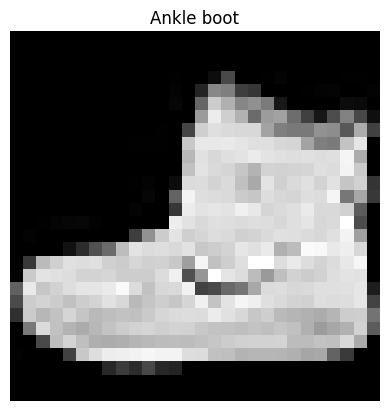

In [8]:
## 1.2 Visualize our data
import matplotlib.pyplot as plt
image, label = train_data[0]
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)

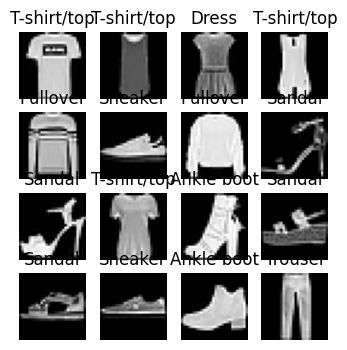

In [9]:
# Plot more images
# torch.manual_seed(42)
fig = plt.figure(figsize=(4,4))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
  random_idx = torch.randint(0, len(train_data), size=[1]).item()
  image, label = train_data[i]
  fig.add_subplot(rows, cols, i)
  plt.imshow(image.squeeze(),cmap="gray")
  plt.title(class_names[label])
  plt.axis(False)

Do you think these items of clothing (images) could be modelled with pure linear lines, or nonlinearities?

## 2. Prepare DataLoader

DataLoader turns our dataset into a Python iterable.

We want to turn our data into minibatches.

In [10]:
from torch.utils.data import DataLoader

# Setup the batch size
BATCH_SIZE = 32

# Turn datasets into iterables (batches)
train_dataloader = DataLoader(train_data,
                              batch_size=BATCH_SIZE,
                              shuffle=True)

test_dataloader = DataLoader(test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=False)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7e687490b500>,
 <torch.utils.data.dataloader.DataLoader at 0x7e68748d5b20>)

In [11]:
# Let's check out what we've created
print(f"DataLoaders: {train_dataloader, test_dataloader}")
print(f"Length of train_dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}...")
print(f"Length of test_dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}...")

DataLoaders: (<torch.utils.data.dataloader.DataLoader object at 0x7e687490b500>, <torch.utils.data.dataloader.DataLoader object at 0x7e68748d5b20>)
Length of train_dataloader: 1875 batches of 32...
Length of test_dataloader: 313 batches of 32...


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

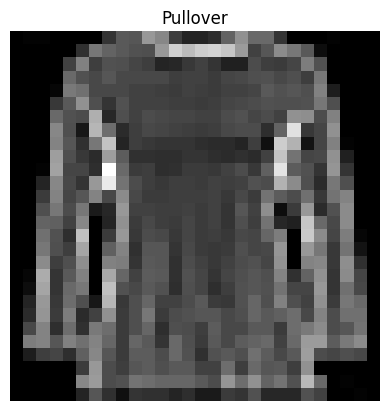

In [12]:
# Show a sample
torch.manual_seed(42)
image_batch, label_batch = next(iter(train_dataloader))
rand_idx = torch.randint(0,len(label_batch),size=[1]).item()
image, label = image_batch[rand_idx], label_batch[rand_idx]
plt.imshow(image.squeeze(),cmap="gray")
plt.title(class_names[label])
plt.axis(False)

## 3. Model 0: Build a baseline model

A baseline model is a simple model you will try and improve upon

In [13]:
# Create a flatten layer
flatten_model = nn.Flatten()

# Get a single sample
x = image_batch[0]
output = flatten_model(x) # perform forward pass

# Print out
print(f"Shape before flattening: {x.shape} -> [color_channels, height, width]")
print(f"Shape after flattening: {output.shape} -> [color_channels, height * width]")

Shape before flattening: torch.Size([1, 28, 28]) -> [color_channels, height, width]
Shape after flattening: torch.Size([1, 784]) -> [color_channels, height * width]


In [14]:
from torch import nn
class FashionMNISTModelV0(nn.Module):
  def __init__(self,
               input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.layer_stack = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=input_shape,
                  out_features=hidden_units),
        nn.ReLU(),
        nn.Linear(in_features=hidden_units,
                  out_features=output_shape)
    )

  def forward(self, x):
    return self.layer_stack(x)

torch.manual_seed(42)
model_0 = FashionMNISTModelV0(input_shape=784, # <- 28 * 28
                               hidden_units=16,
                               output_shape=len(class_names)).to("cpu")

model_0

FashionMNISTModelV0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=16, bias=True)
    (2): ReLU()
    (3): Linear(in_features=16, out_features=10, bias=True)
  )
)

In [15]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0313, -0.0194, -0.0231,  ...,  0.0165,  0.0038,  0.0114],
                      [-0.0301, -0.0315, -0.0168,  ...,  0.0032,  0.0287, -0.0005],
                      [-0.0150, -0.0167, -0.0028,  ...,  0.0172,  0.0117, -0.0291]])),
             ('layer_stack.1.bias',
              tensor([ 0.0214,  0.0289,  0.0107,  0.0284, -0.0170, -0.0234, -0.0287, -0.0056,
                      -0.0035, -0.0203, -0.0122, -0.0115,  0.0344, -0.0026,  0.0290,  0.0034])),
             ('layer_stack.3.weight',
              tensor([[ 0.0891,  0.1441, -0.2301, -0.1127, -0.1900,  0.2429,  0.0917, -0.1048,
                       -0.1885,  0.1384,  0.0580, -0.1230, -0.1814, 

In [16]:
with torch.inference_mode():
  y_pred = model_0(image_batch[0])
y_pred

tensor([[ 0.0712, -0.0648, -0.1311,  0.1173,  0.1007, -0.0199, -0.1043, -0.2492,
          0.1589,  0.2052]])

### 3.1 Setup loss, optimizer and evaluate metrics

* Loss function -> `nn.EntrophyLoss()`
* Optimizer -> `torch.optim.SGD()`
* Accuracy -> `torchmetrics.Accuracy()`

In [17]:
import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download...")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)



In [18]:
# Import accuracy metric
from helper_functions import accuracy_fn

# Setup loss func and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.1)


### 3.2 Creating a function to time our experiments

We often want to check the following:
1. Model's performance
2. How fast it runs

In [19]:
from timeit import default_timer as timer
def print_train_time(start: float, end: float, tdevice: str = None):
    """Prints duration"""
    total_time = end - start
    print(f"Train time on {tdevice}: {total_time:.3f} seconds")
    return total_time


start_time = timer()
# some code...
end_time = timer()
print_train_time(start=start_time,
                 end=end_time,
                 tdevice="cpu")

Train time on cpu: 0.000 seconds


2.160400026696152e-05

### 3.3 Creating a training loop

1. Loop through epochs
2. Loop through training batches, calculate the train loss *per batch*
3. Loop thought testing batches, calculate the test loss #per batch*
4. Time it all

In [20]:
# Import tqdm for the progress bar <- very good for visualize
from tqdm.auto import tqdm

# Set the seed and start the timer
torch.manual_seed(42)
train_time_start_on_cpu = timer()

# Set the number of epoch (keep it small for faster training time)
epochs = 10

# Create a training/testing loop
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n------")
  ### Training
  train_loss = 0
  model_0.train() # <- training mode
  # Add a loop through the training batch
  for batch, (X, y) in enumerate(train_dataloader): # <- per batch of data
    y_pred = model_0(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss # accumulate the loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Print out what's happening
    if batch % 400 == 0:
      print(f"Looked at {batch * len(X)}/{len(train_dataloader.dataset)} samples.")

  # Divide total train loss by length of train dataloader
  train_loss /= len(train_dataloader) # <- average per batch

  ### Testing
  test_loss, test_acc= 0, 0
  model_0.eval()
  with torch.inference_mode():
    for (X, y) in test_dataloader:
      test_pred = model_0(X)
      test_loss += loss_fn(test_pred, y)
      test_acc += accuracy_fn(y_true=y,
                           y_pred=test_pred.argmax(dim=1))
    test_loss /= len(test_dataloader)
    test_acc /= len(test_dataloader)

  # Print out what's happening
  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f}, Test acc: {test_acc:.4f}")

# Calculate training time
train_time_end_on_cpu = timer()
total_train_time_model_0 = print_train_time(start=train_time_start_on_cpu,
                                  end=train_time_end_on_cpu,
                                  tdevice=str(next(model_0.parameters()).device))

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.6155 | Test loss: 0.5193, Test acc: 81.5395
Epoch: 1
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4561 | Test loss: 0.4692, Test acc: 83.2368
Epoch: 2
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.4218 | Test loss: 0.4369, Test acc: 84.6246
Epoch: 3
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 samples.
Looked at 38400/60000 samples.
Looked at 51200/60000 samples.

Train loss: 0.3990 | Test loss: 0.4257, Test acc: 85.0938
Epoch: 4
------
Looked at 0/60000 samples.
Looked at 12800/60000 samples.
Looked at 25600/60000 

## 4. Make predictions and get Model 0 results

In [21]:
torch.manual_seed(42)
def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn):
  """Returns a dictionary contraining the model results"""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      # Make pred
      pred = model(X)
      loss += loss_fn(pred, y)
      acc += accuracy_fn(y_true=y,
                         y_pred=pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)
  return {"model_name": model.__class__.__name__, # only works for models created with a class
          "model_loss": loss.item(),
          "model_acc": acc}

# Calculate model 0 results on test dataset
model_0_results = eval_model(model=model_0,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn)
model_0_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.3931947350502014,
 'model_acc': 85.8526357827476}

## 5. Setup device agnostic-code (use a GPU is possible)


In [22]:
!nvidia-smi

Wed May 27 17:41:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [23]:
# Setup device-agnostic code
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [24]:
from timeit import default_timer as timer
def print_train_time(start:float,
                     end:float,
                     tdevice: torch.device=None):
  """Prints duration"""
  total_time = end - start
  print(f"Train time on {tdevice}: {total_time:.3f} seconds")
  return total_time


### Create the training/testing function
* `train_step` <- one training epoch
* `test_step` <- one testing epoch

In [25]:
def train_step(model: torch.nn.Module,
            data_loader: torch.utils.data.DataLoader,
            loss_fn: torch.nn.Module,
            optimizer: torch.optim.Optimizer,
            accuracy_fn,
            device: torch.device = device):
  train_loss, train_acc = 0, 0
  model.train()
  for batch, (X, y) in enumerate(data_loader):
    X, y = X.to(device), y.to(device)
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    train_loss += loss.item()
    train_acc += accuracy_fn(y_true=y,
                             y_pred=y_pred.argmax(dim=1))
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

  train_loss /= len(data_loader)
  train_acc /= len(data_loader)
  print(f"Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")

def test_step(model: torch.nn.Module,
            data_loader: torch.utils.data.DataLoader,
            loss_fn: torch.nn.Module,
            accuracy_fn,
            device: torch.device = device):
  test_loss, test_acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for batch, (X, y) in enumerate(data_loader):
      X, y = X.to(device), y.to(device)
      y_pred = model(X)
      loss = loss_fn(y_pred, y)
      test_loss += loss.item()
      test_acc += accuracy_fn(y_true=y,
                              y_pred=y_pred.argmax(dim=1))

  test_loss /= len(data_loader)
  test_acc /= len(data_loader)
  print(f"Test loss: {test_loss:.4f} | Test acc: {test_acc:.4f}")

def print_train_time(start:float,
                     end:float,
                     tdevice: torch.device=None):
  """Prints duration"""
  total_time = end - start
  print(f"Train time on {tdevice}: {total_time:.3f} seconds")
  return total_time

def eval_model(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device = device):
  """Returns a dictionary contraining the model results"""
  loss, acc = 0, 0
  model.eval()
  with torch.inference_mode():
    for X, y in tqdm(data_loader):
      # Make pred
      X, y = X.to(device), y.to(device)
      pred = model(X)
      loss += loss_fn(pred, y)
      acc += accuracy_fn(y_true=y,
                          y_pred=pred.argmax(dim=1))

    loss /= len(data_loader)
    acc /= len(data_loader)
  return {"model_name": model.__class__.__name__, # only works for models created with a class
          "model_loss": loss.item(),
          "model_acc": acc}

### start training

In [26]:
torch.manual_seed(42)
from timeit import default_timer as timer
from tqdm.auto import tqdm
train_time_start_on_gpu = timer()

model_1 = FashionMNISTModelV0(input_shape=784,
                              hidden_units=16,
                              output_shape=len(class_names)).to(device)
optimizer = torch.optim.SGD(params=model_1.parameters(),
                            lr=0.1)
loss_fn = nn.CrossEntropyLoss()

import requests
from pathlib import Path

# Download helper functions from Learn PyTorch repo
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download...")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

# Import accuracy metric
from helper_functions import accuracy_fn


# Set epochs
epochs = 10

# Create training loop
train_time_start_on_gpu = timer()

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n------")
  train_step(model=model_1,
            data_loader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
            device=device)
  test_step(model=model_1,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_on_gpu = timer()
total_train_time_model_1 = print_train_time(start=train_time_start_on_gpu,
                                  end=train_time_end_on_gpu,
                                  tdevice=device)


helper_functions.py already exists, skipping download...


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0
------
Train loss: 0.6022 | Train acc: 78.4783
Test loss: 0.5054 | Test acc: 82.1086
Epoch: 1
------
Train loss: 0.4450 | Train acc: 83.9317
Test loss: 0.4332 | Test acc: 84.7244
Epoch: 2
------
Train loss: 0.4112 | Train acc: 85.2183
Test loss: 0.4327 | Test acc: 84.4848
Epoch: 3
------
Train loss: 0.3920 | Train acc: 85.7500
Test loss: 0.4410 | Test acc: 84.2951
Epoch: 4
------
Train loss: 0.3785 | Train acc: 86.2317
Test loss: 0.4239 | Test acc: 84.8043
Epoch: 5
------
Train loss: 0.3673 | Train acc: 86.3767
Test loss: 0.4125 | Test acc: 85.2436
Epoch: 6
------
Train loss: 0.3606 | Train acc: 86.7050
Test loss: 0.4260 | Test acc: 85.2336
Epoch: 7
------
Train loss: 0.3541 | Train acc: 87.0033
Test loss: 0.4031 | Test acc: 85.8027
Epoch: 8
------
Train loss: 0.3484 | Train acc: 87.1800
Test loss: 0.4120 | Test acc: 84.8442
Epoch: 9
------
Train loss: 0.3420 | Train acc: 87.4517
Test loss: 0.3985 | Test acc: 85.6629
Train time on cuda: 96.311 seconds


### Evaluate the model

In [27]:
eval_model(model=model_1,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn)

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.39852434396743774,
 'model_acc': 85.6629392971246}

In [28]:
eval_model(model=model_0,
        data_loader=test_dataloader,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        device='cpu')

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.3931947350502014,
 'model_acc': 85.8526357827476}

## Model 2: Building a Convolutional Neural

very nice visual and interactive tool
https://poloclub.github.io/cnn-explainer/



In [29]:
# Creata a CNN
class FashionMNISTModelV2(nn.Module):
  """
  Model architecture that replicates the Tiny VGG model from CNN explainer
  """
  def __init__(self, input_shape: int,
               hidden_units: int,
               output_shape: int):
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        # Create a Conv block
        nn.Conv2d(in_channels=input_shape, # <- this is # of color channels
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1), # kernel_size, stride, padding are hyperparameters
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1,
                  padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units*7*7, # there's a trick calculating this
                  out_features=output_shape)
    )

  def forward(self, x):
    x1 = self.conv_block_1(x)
    x2 = self.conv_block_2(x1)
    x3 = self.classifier(x2)
    return x3



In [30]:
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape=1,
                          hidden_units=10,
                          output_shape=len(class_names)).to(device)

### 7.1. Stepping through `nn.Conv2d()`

In [31]:
torch.manual_seed(42)

# Create a batch of images
images = torch.randn(size=(32, 3, 64, 64))
test_image = images[0]

print(f"Image batch shape: {images.shape}")
print(f"Single image shape: {test_image.shape}")
print(f"Test image:\n {test_image}")

Image batch shape: torch.Size([32, 3, 64, 64])
Single image shape: torch.Size([3, 64, 64])
Test image:
 tensor([[[ 1.9269,  1.4873,  0.9007,  ...,  1.8446, -1.1845,  1.3835],
         [ 1.4451,  0.8564,  2.2181,  ...,  0.3399,  0.7200,  0.4114],
         [ 1.9312,  1.0119, -1.4364,  ..., -0.5558,  0.7043,  0.7099],
         ...,
         [-0.5610, -0.4830,  0.4770,  ..., -0.2713, -0.9537, -0.6737],
         [ 0.3076, -0.1277,  0.0366,  ..., -2.0060,  0.2824, -0.8111],
         [-1.5486,  0.0485, -0.7712,  ..., -0.1403,  0.9416, -0.0118]],

        [[-0.5197,  1.8524,  1.8365,  ...,  0.8935, -1.5114, -0.8515],
         [ 2.0818,  1.0677, -1.4277,  ...,  1.6612, -2.6223, -0.4319],
         [-0.1010, -0.4388, -1.9775,  ...,  0.2106,  0.2536, -0.7318],
         ...,
         [ 0.2779,  0.7342, -0.3736,  ..., -0.4601,  0.1815,  0.1850],
         [ 0.7205, -0.2833,  0.0937,  ..., -0.1002, -2.3609,  2.2465],
         [-1.3242, -0.1973,  0.2920,  ...,  0.5409,  0.6940,  1.8563]],

        [[-0

In [32]:
# Create a single conv2d layer
conv_layer = nn.Conv2d(in_channels=3,
                       out_channels=10,
                       kernel_size=3,
                       stride=1,
                       padding=0)

# Pass the data through the Conv layer
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 62, 62])

In [33]:
torch.version

<module 'torch.version' from '/usr/local/lib/python3.12/dist-packages/torch/version.py'>

In [34]:
torch.__version__

'2.11.0+cu128'

### 7.2 Stepping through `nn.MaxPool2d()`

In [35]:
test_image.shape

torch.Size([3, 64, 64])

In [36]:
# MaxPooling
max_pool_layer = nn.MaxPool2d(kernel_size=2)
max_pool_output = max_pool_layer(test_image)
max_pool_output.shape

torch.Size([3, 32, 32])

In [37]:
# test VGG on random image
rand_image_tensor = torch.randn(size=(1, 28, 28)).to(device)
model_2(rand_image_tensor.unsqueeze(dim=0)).to(device)

tensor([[ 0.0426, -0.0984,  0.0621, -0.0358,  0.0184,  0.0271,  0.0163,  0.0133,
         -0.0038, -0.0115]], device='cuda:0', grad_fn=<AddmmBackward0>)

### 7.3 Setup a loss func and an optimizer for model 2


In [38]:
# setup loss and optim
from helper_functions import accuracy_fn

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)


### 7.4 training and testing `model_2` using our functions

In [39]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Measure time
from timeit import default_timer as timer
train_time_start_model_2 = timer()

# Train and test model
epochs = 5
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n------")
  train_step(model=model_2,
             data_loader=train_dataloader,
             loss_fn=loss_fn,
             optimizer=optimizer,
             accuracy_fn=accuracy_fn,
             device=device)
  test_step(model=model_2,
            data_loader=test_dataloader,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            device=device)

train_time_end_model_2 = timer()
total_train_time_model_2 = print_train_time(start=train_time_start_model_2,
                                  end=train_time_end_model_2,
                                  tdevice=device)

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
------
Train loss: 0.5945 | Train acc: 78.4783
Test loss: 0.3926 | Test acc: 85.6130
Epoch: 1
------
Train loss: 0.3589 | Train acc: 87.1100
Test loss: 0.3565 | Test acc: 86.6913
Epoch: 2
------
Train loss: 0.3233 | Train acc: 88.2867
Test loss: 0.3239 | Test acc: 88.2288
Epoch: 3
------
Train loss: 0.3034 | Train acc: 88.9600
Test loss: 0.3230 | Test acc: 88.1889
Epoch: 4
------
Train loss: 0.2893 | Train acc: 89.5267
Test loss: 0.2998 | Test acc: 89.2073
Train time on cuda: 58.527 seconds


In [40]:
# Get model_2 result
model_2_results = eval_model(model=model_2,
                             data_loader=test_dataloader,
                             loss_fn=loss_fn,
                             accuracy_fn=accuracy_fn,
                             device=device)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.29982519149780273,
 'model_acc': 89.20726837060703}

In [41]:
model_0_results

{'model_name': 'FashionMNISTModelV0',
 'model_loss': 0.3931947350502014,
 'model_acc': 85.8526357827476}

In [42]:
## 8. Compare model resuls and training time
import pandas as pd
compare_results = pd.DataFrame([model_0_results,
                                model_2_results])
compare_results

,model_name,model_loss,model_acc
0,FashionMNISTModelV0,0.393195,85.852636
1,FashionMNISTModelV2,0.299825,89.207268


In [43]:
# Add training time to results comparison
compare_results["training_time"] = [total_train_time_model_0,
                                     total_train_time_model_2]
compare_results

,model_name,model_loss,model_acc,training_time
0,FashionMNISTModelV0,0.393195,85.852636,87.339321
1,FashionMNISTModelV2,0.299825,89.207268,58.527113


Text(0, 0.5, 'model')

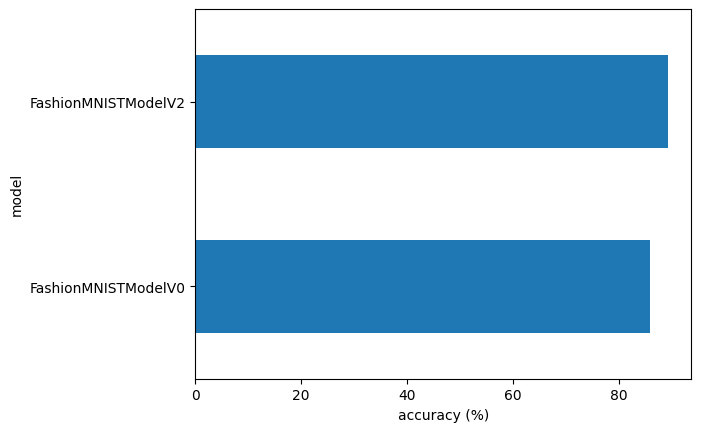

In [44]:
# Visualize our model results
compare_results.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy (%)")
plt.ylabel("model")

In [45]:
## 9. Make and evaluate random predictions with the best model
def make_predictions(model: torch.nn.Module,
                     data: list,
                     device: torch.device=device):
  pred_probs = []
  model.to(device)
  model.eval()
  with torch.inference_mode():
    for sample in data:
      # prepare the sample (add batch dim and pass to device)
      sample = torch.unsqueeze(sample, dim=0).to(device)
      # forward pass
      pred_logit = model(sample)
      # get prediction prob
      pred_prob = torch.softmax(pred_logit.squeeze(), dim=0)
      # get pred prob off the GPU
      pred_probs.append(pred_prob.cpu())
  return torch.stack(pred_probs)

In [46]:
test_data

Dataset FashionMNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [47]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
  test_samples.append(sample)
  test_labels.append(label)

# View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sandal')

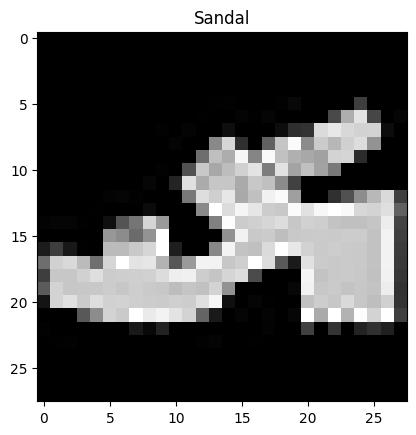

In [48]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [49]:
# Make predictions
pred_probs = make_predictions(model=model_2,
                              data=test_samples)
pred_labels = pred_probs.argmax(dim=1)
pred_labels

tensor([5, 1, 7, 4, 3, 0, 4, 7, 1])

In [50]:
pred_probs.shape

torch.Size([9, 10])

In [51]:
test_labels

[5, 1, 7, 4, 3, 0, 4, 7, 1]

Text(0.5, 1.0, 'Trouser')

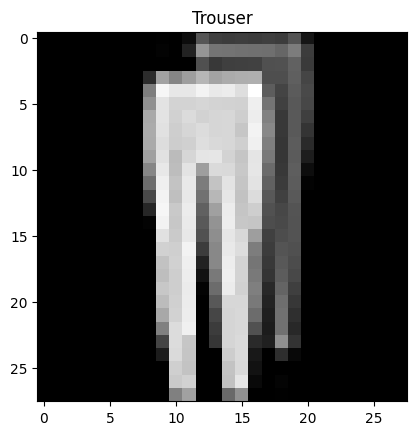

In [52]:
plt.imshow(test_samples[1].squeeze(),cmap='gray')
plt.title(class_names[test_labels[1]])

In [53]:
class_names[pred_labels[1]]

'Trouser'

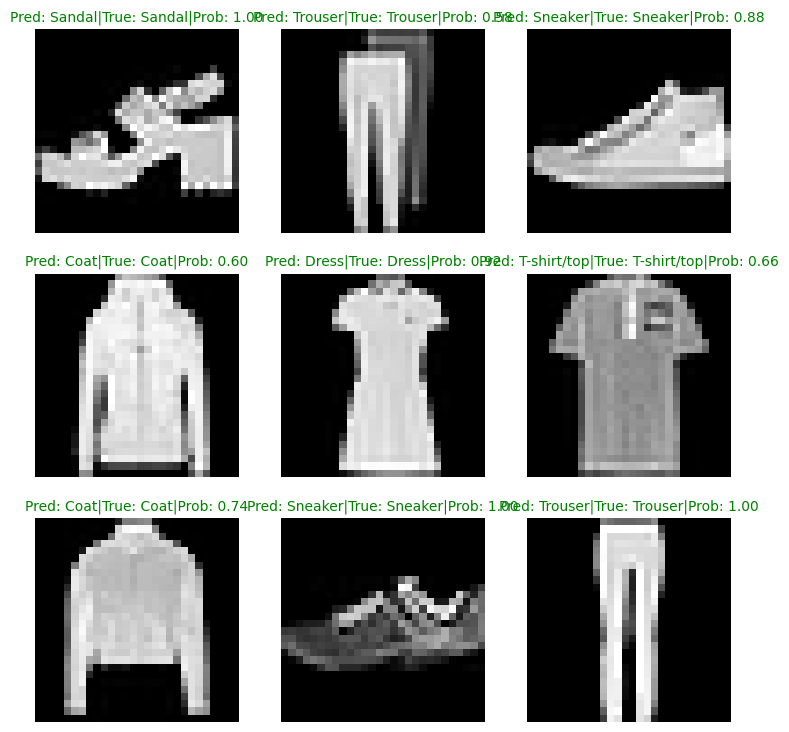

In [54]:
# Plot predictions
plt.figure(figsize=(9,9))
nrows = 3
nclos = 3
for i, sample in enumerate(test_samples):
  # Create subplot
  plt.subplot(nrows, nclos, i+1)
  # Plot the target image
  plt.imshow(sample.squeeze(), cmap="gray")
  # Find the prediction label
  pred_label = class_names[pred_labels[i]]
  pred_prob = pred_probs[i,pred_labels[i]]
  # Find teh true label
  true_label = class_names[test_labels[i]]
  # Create a title
  title_test = f"Pred: {pred_label}|True: {true_label}|Prob: {pred_prob:.2f}"
  # change color of title if predictio is wrong
  if pred_label == true_label:
    plt.title(title_test, fontsize=10, c="g")
  else:
    plt.title(title_test, fontsize=10, c="r")
  plt.axis(False)

## 10. Making a confusion matrix for further prediction evaluation

A confusion matrix is one of metrics used to evaluate the performance of a classification model.

1. Make prediction with our model
2. use `torchmetrics.ConfusionMatrix`
3. Plot the confusion matrix using `mlxtend.plotting.plot_confusion_matrix()`

In [55]:
# Import tqdm.auto
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
model_2.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions..."):
    X, y = X.to(device), y.to(device)
    y_logit = model_2(X)
    y_pred = torch.softmax(y_logit.squeeze(), dim=0).argmax(dim=1)
    y_preds.append(y_pred.cpu())

# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)

Making predictions...:   0%|          | 0/313 [00:00<?, ?it/s]

In [56]:
!pip install torchmetrics
import torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.7 MB/s eta 0:00:00


In [57]:
# See if required packages are installed, if not install them...
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend version should be 0.19.0 or higher"
except:
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"mlxtend version {mlxtend.__version__}")

mlxtend version 0.23.4


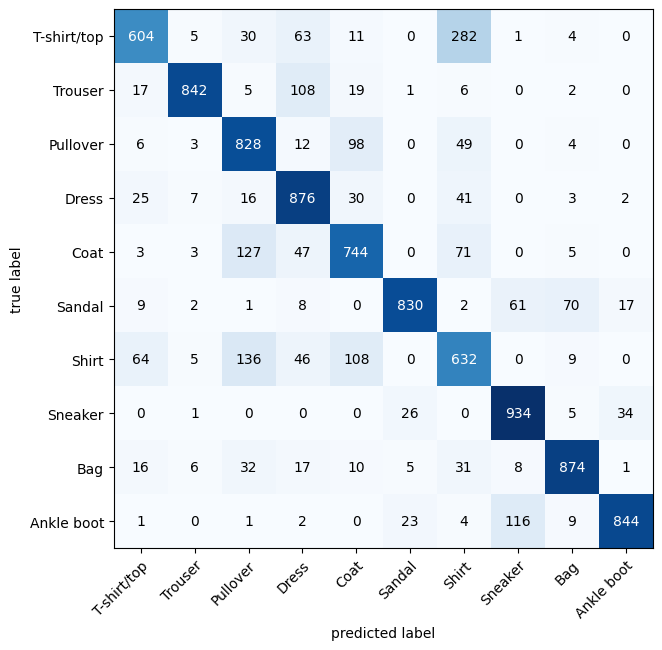

In [58]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(task='multiclass',num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

# 3. Plot the confusion matrix
fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10,7)
)


In [59]:
!pip install torchinfo

from torchinfo import summary

# For Model 2
summary(model_2, input_size=(1, 1, 28, 28))  # batch_size=1, 1 channel, 28x28 image

Layer (type:depth-idx)                   Output Shape              Param #
FashionMNISTModelV2                      [1, 10]                   --
├─Sequential: 1-1                        [1, 10, 14, 14]           --
│    └─Conv2d: 2-1                       [1, 10, 28, 28]           100
│    └─ReLU: 2-2                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-3                       [1, 10, 28, 28]           910
│    └─ReLU: 2-4                         [1, 10, 28, 28]           --
│    └─MaxPool2d: 2-5                    [1, 10, 14, 14]           --
├─Sequential: 1-2                        [1, 10, 7, 7]             --
│    └─Conv2d: 2-6                       [1, 10, 14, 14]           910
│    └─ReLU: 2-7                         [1, 10, 14, 14]           --
│    └─Conv2d: 2-8                       [1, 10, 14, 14]           910
│    └─ReLU: 2-9                         [1, 10, 14, 14]           --
│    └─MaxPool2d: 2-10                   [1, 10, 7, 7]             --
├─Sequentia